# [Prefix-Tuning: Optimizing Continuous Prompts for Generation](https://arxiv.org/pdf/2101.00190)

## Introduction

Fine-tuning is the default way to adapt large pretrained language models to a new task, but it modifies every parameter of the model, so a full copy must be stored for each task — an increasingly expensive proposition as models grow. This is especially costly for generation tasks (the paper studies table-to-text generation with GPT-2 and summarization with BART), where a separate large model per task compounds quickly.

[Adapters](https://arxiv.org/pdf/1902.00751) address the storage problem by inserting small trainable modules inside each layer, but that still changes the network's forward computation at every layer. Prefix-tuning takes a different, prompting-inspired approach: rather than modifying the network's internal structure, it steers the entirely frozen model purely through a small set of extra "virtual" inputs.

## Approach

Prefix-tuning prepends a small number of trainable, continuous vectors directly to the key and value tensors of every attention layer, so real tokens can attend to this learned prefix exactly as if it were part of the input — without it ever being detokenized or corresponding to real vocabulary. All pretrained weights stay frozen; only the prefix is trained.

To keep optimization stable, the paper reparameterizes the prefix through a small MLP over a lower-dimensional embedding during training (this MLP is discarded after training; only the resulting prefix vectors it produces are kept for inference).

## Result

- Learning only about **0.1% of the total parameters**, prefix-tuning matches full fine-tuning's performance in the **full-data** setting on table-to-text generation and summarization.
- In **low-data** settings, prefix-tuning **outperforms** full fine-tuning — training far fewer parameters acts as a strong regularizer against overfitting when examples are scarce.
- Prefix-tuning also extrapolates better to inputs with topics unseen during training than full fine-tuning does.
- The reparameterization trick (MLP over a smaller embedding) matters for optimization stability; directly optimizing the prefix vectors is more brittle.

## Application

The paper's most distinctive, testable claim is about the **low-data regime**: prefix-tuning should hold up — or even outperform — full fine-tuning as the training set shrinks, because it has far fewer parameters to overfit with. We test this directly: both methods are fine-tuned on the same model (`bert-base-uncased`) for binary toxicity classification (`data/toxicity_en.csv`) at **two training-set sizes** — the full training split and a small low-data subset — and compared on trainable parameter count and test accuracy/F1 at each size.

In [1]:
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "bert-base-uncased"
print("Using device:", device)

Using device: cuda


In [2]:
df = pd.read_csv("data/toxicity_en.csv")
df["is_toxic"] = (df["is_toxic"] == "Toxic").astype(int)

train_df, test_df = train_test_split(
    df, test_size=0.15, random_state=42, stratify=df["is_toxic"]
)
print(f"train (full): {len(train_df)}, test: {len(test_df)}")
df["is_toxic"].value_counts()

train (full): 850, test: 150


is_toxic
1    501
0    499
Name: count, dtype: int64

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class ToxicDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts = df["text"].values
        self.labels = df["is_toxic"].values
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float),
        }


BATCH_SIZE = 16
test_dataset = ToxicDataset(test_df, tokenizer)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Full-data training split
full_train_dataset = ToxicDataset(train_df, tokenizer)
full_train_dataloader = DataLoader(full_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Low-data training split: a small stratified subsample of the training data, to test the
# paper's claim that prefix-tuning holds up better than full fine-tuning when data is scarce.
LOW_DATA_N = 80  # ~9% of the full training split
low_train_df, _ = train_test_split(
    train_df, train_size=LOW_DATA_N, random_state=42, stratify=train_df["is_toxic"]
)
low_train_dataset = ToxicDataset(low_train_df, tokenizer)
low_train_dataloader = DataLoader(low_train_dataset, batch_size=8, shuffle=True)

print(f"full train: {len(full_train_dataset)}, low-data train: {len(low_train_dataset)}, test: {len(test_dataset)}")
low_train_df["is_toxic"].value_counts()

full train: 850, low-data train: 80, test: 150


is_toxic
1    40
0    40
Name: count, dtype: int64

### Shared training/evaluation harness

Both methods plug into the same harness: it takes a (possibly frozen/wrapped) `backbone`, a fresh `classifier` head, the list of `trainable_params` for the optimizer, a `forward_fn` that returns the `[CLS]` embedding, and — unlike a single-setting comparison — an explicit `train_loader` so we can re-run each method at both the full and low-data training-set sizes.

In [4]:
class ClassifierHead(nn.Module):
    def __init__(self, hidden_size=768, output_size=1):
        super().__init__()
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        return self.linear(x)


def count_trainable_params(*modules):
    return sum(p.numel() for m in modules for p in m.parameters() if p.requires_grad)


results = []


def train_and_evaluate(name, backbone, classifier, trainable_params, forward_fn, train_loader, epochs=3, lr=2e-5):
    """Trains `backbone` + `classifier` on `train_loader`, measuring efficiency and performance.

    `forward_fn(backbone, input_ids, attention_mask) -> cls_embedding (B, H)` abstracts
    away how each method feeds the model.
    """
    backbone.to(device)
    classifier.to(device)
    optimizer = torch.optim.AdamW(trainable_params, lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    if device == "cuda":
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()

    step_times = []
    backbone.train()
    classifier.train()
    for epoch in range(epochs):
        loop = tqdm(train_loader, desc=f"[{name}] epoch {epoch + 1}/{epochs}", leave=False)
        for batch in loop:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            if device == "cuda":
                torch.cuda.synchronize()
            t0 = time.time()

            optimizer.zero_grad()
            cls_emb = forward_fn(backbone, input_ids, attention_mask)
            logits = classifier(cls_emb).squeeze(-1)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            if device == "cuda":
                torch.cuda.synchronize()
            step_times.append(time.time() - t0)
            loop.set_postfix(loss=loss.item())

    peak_mem_mb = torch.cuda.max_memory_allocated() / 1024**2 if device == "cuda" else float("nan")
    warm_steps = step_times[5:] if len(step_times) > 5 else step_times
    avg_step_ms = 1000 * float(np.mean(warm_steps))

    backbone.eval()
    classifier.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(test_dataloader, desc=f"[{name}] testing", leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"]

            cls_emb = forward_fn(backbone, input_ids, attention_mask)
            logits = classifier(cls_emb).squeeze(-1)
            preds = (torch.sigmoid(logits) > 0.5).long().cpu()

            all_preds.extend(preds.tolist())
            all_labels.extend(labels.long().tolist())

    result = {
        "method": name,
        "train_size": len(train_loader.dataset),
        "trainable_params": count_trainable_params(backbone, classifier),
        "peak_mem_mb": peak_mem_mb,
        "avg_step_ms": avg_step_ms,
        "accuracy": accuracy_score(all_labels, all_preds),
        "f1": f1_score(all_labels, all_preds),
    }
    results.append(result)
    return result

### 1. Full Fine-Tuning (baseline)

Every parameter of BERT, plus the classifier head, is updated. With 109M+ trainable parameters and only a small dataset, this is exactly the regime where the paper predicts full fine-tuning is prone to overfitting.

In [5]:
def build_full_finetune():
    backbone = AutoModel.from_pretrained(MODEL_NAME)
    for p in backbone.parameters():
        p.requires_grad = True
    classifier = ClassifierHead()

    def forward_fn(backbone, input_ids, attention_mask):
        out = backbone(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:, 0, :]

    trainable_params = list(backbone.parameters()) + list(classifier.parameters())
    return backbone, classifier, trainable_params, forward_fn


backbone, classifier, trainable_params, forward_fn = build_full_finetune()
train_and_evaluate(
    "Full Fine-Tuning (full data)", backbone, classifier, trainable_params, forward_fn,
    train_loader=full_train_dataloader, epochs=3, lr=2e-5,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Full Fine-Tuning (full data)] epoch 1/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Full Fine-Tuning (full data)] epoch 2/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Full Fine-Tuning (full data)] epoch 3/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Full Fine-Tuning (full data)] testing:   0%|          | 0/10 [00:00<?, ?it/s]

{'method': 'Full Fine-Tuning (full data)',
 'train_size': 850,
 'trainable_params': 109483009,
 'peak_mem_mb': 2536.72412109375,
 'avg_step_ms': 119.15186408219064,
 'accuracy': 0.9533333333333334,
 'f1': 0.9530201342281879}

### 2. Prefix-Tuning

Each self-attention layer gets its own trainable "virtual" key/value vectors (a prefix) that are prepended to the real keys/values before the attention softmax, so every token can attend to them. The prefix never joins the residual stream or the output sequence — it only steers attention — so the `[CLS]` position is unchanged. All original BERT weights stay frozen; only the per-layer prefixes and the classifier head are trained.

We skip the paper's MLP reparameterization (it's a training-stability trick for larger prefixes/models — with `prefix_len=10` on BERT-base it isn't needed) and train the prefix vectors directly, matching the paper's *inference-time* representation.

**Implementation note:** this `transformers` version routes attention through an internal `Cache`/masking API that changes across versions. To stay self-contained and version-robust, we replace each layer's self-attention `forward` with a small scaled-dot-product implementation that concatenates the learned prefix K/V and rebuilds the padding mask directly from the batch's attention mask (stashed on the module beforehand), rather than depending on internal mask utilities.

In [6]:
class PrefixEncoder(nn.Module):
    def __init__(self, num_heads, head_dim, prefix_len=10):
        super().__init__()
        self.prefix_len = prefix_len
        self.prefix_k = nn.Parameter(torch.randn(num_heads, prefix_len, head_dim) * 0.02)
        self.prefix_v = nn.Parameter(torch.randn(num_heads, prefix_len, head_dim) * 0.02)


def patch_self_attention_with_prefix(self_attn, prefix_encoder):
    """Replaces `self_attn.forward` so learned prefix K/V are attended to alongside real tokens."""

    def forward(hidden_states, attention_mask=None, past_key_values=None, **kwargs):
        B, S, _ = hidden_states.shape
        H, D = self_attn.num_attention_heads, self_attn.attention_head_size
        shape = (B, S, H, D)

        q = self_attn.query(hidden_states).view(*shape).transpose(1, 2)
        k = self_attn.key(hidden_states).view(*shape).transpose(1, 2)
        v = self_attn.value(hidden_states).view(*shape).transpose(1, 2)

        pk = prefix_encoder.prefix_k.unsqueeze(0).expand(B, -1, -1, -1).to(k.dtype)
        pv = prefix_encoder.prefix_v.unsqueeze(0).expand(B, -1, -1, -1).to(v.dtype)
        k = torch.cat([pk, k], dim=2)
        v = torch.cat([pv, v], dim=2)

        pad_mask = self_attn._padding_mask.to(q.dtype)  # (B, S), stashed by forward_fn below
        prefix_ones = torch.ones(B, prefix_encoder.prefix_len, device=pad_mask.device, dtype=pad_mask.dtype)
        full_mask = torch.cat([prefix_ones, pad_mask], dim=1)
        additive_mask = (1.0 - full_mask)[:, None, None, :] * torch.finfo(q.dtype).min

        attn_scores = torch.matmul(q, k.transpose(-1, -2)) * self_attn.scaling + additive_mask
        attn_probs = F.softmax(attn_scores, dim=-1)
        context = torch.matmul(attn_probs, v).transpose(1, 2).reshape(B, S, -1)
        return (context, attn_probs)

    self_attn.forward = forward


def build_prefix_tuning(prefix_len=10):
    backbone = AutoModel.from_pretrained(MODEL_NAME)
    for p in backbone.parameters():
        p.requires_grad = False

    num_heads = backbone.config.num_attention_heads
    head_dim = backbone.config.hidden_size // num_heads
    prefix_encoders = nn.ModuleList(
        [PrefixEncoder(num_heads, head_dim, prefix_len) for _ in backbone.encoder.layer]
    )
    for layer, enc in zip(backbone.encoder.layer, prefix_encoders):
        patch_self_attention_with_prefix(layer.attention.self, enc)
    backbone.injected_prefixes = prefix_encoders

    classifier = ClassifierHead()

    def forward_fn(backbone, input_ids, attention_mask):
        for layer in backbone.encoder.layer:
            layer.attention.self._padding_mask = attention_mask
        out = backbone(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:, 0, :]  # CLS position unchanged: prefix never joins the sequence

    trainable_params = list(prefix_encoders.parameters()) + list(classifier.parameters())
    return backbone, classifier, trainable_params, forward_fn


backbone, classifier, trainable_params, forward_fn = build_prefix_tuning()
train_and_evaluate(
    "Prefix-Tuning (full data)", backbone, classifier, trainable_params, forward_fn,
    train_loader=full_train_dataloader, epochs=3, lr=1e-3,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Prefix-Tuning (full data)] epoch 1/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Prefix-Tuning (full data)] epoch 2/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Prefix-Tuning (full data)] epoch 3/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Prefix-Tuning (full data)] testing:   0%|          | 0/10 [00:00<?, ?it/s]

{'method': 'Prefix-Tuning (full data)',
 'train_size': 850,
 'trainable_params': 185089,
 'peak_mem_mb': 1356.5380859375,
 'avg_step_ms': 74.34718775901065,
 'accuracy': 0.8733333333333333,
 'f1': 0.8633093525179856}

### 3. The Low-Data Regime

We now retrain **fresh** copies of both methods (never touching the ones already trained above) on the small `low_train_dataloader` (80 examples) instead of the full training split, then evaluate on the same held-out test set. Because there are far fewer steps per epoch, we train for more epochs so both settings see a broadly comparable number of gradient updates.

In [7]:
backbone, classifier, trainable_params, forward_fn = build_full_finetune()
train_and_evaluate(
    "Full Fine-Tuning (low data)", backbone, classifier, trainable_params, forward_fn,
    train_loader=low_train_dataloader, epochs=15, lr=2e-5,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Full Fine-Tuning (low data)] epoch 1/15:   0%|          | 0/10 [00:00<?, ?it/s]

[Full Fine-Tuning (low data)] epoch 2/15:   0%|          | 0/10 [00:00<?, ?it/s]

[Full Fine-Tuning (low data)] epoch 3/15:   0%|          | 0/10 [00:00<?, ?it/s]

...

[Full Fine-Tuning (low data)] epoch 13/15:   0%|          | 0/10 [00:00<?, ?it/s]

[Full Fine-Tuning (low data)] epoch 14/15:   0%|          | 0/10 [00:00<?, ?it/s]

[Full Fine-Tuning (low data)] epoch 15/15:   0%|          | 0/10 [00:00<?, ?it/s]

[Full Fine-Tuning (low data)] testing:   0%|          | 0/10 [00:00<?, ?it/s]

{'method': 'Full Fine-Tuning (low data)',
 'train_size': 80,
 'trainable_params': 109483009,
 'peak_mem_mb': 2227.90625,
 'avg_step_ms': 76.55563354492188,
 'accuracy': 0.8733333333333333,
 'f1': 0.8652482269503546}

In [8]:
backbone, classifier, trainable_params, forward_fn = build_prefix_tuning()
train_and_evaluate(
    "Prefix-Tuning (low data)", backbone, classifier, trainable_params, forward_fn,
    train_loader=low_train_dataloader, epochs=15, lr=1e-3,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Prefix-Tuning (low data)] epoch 1/15:   0%|          | 0/10 [00:00<?, ?it/s]

[Prefix-Tuning (low data)] epoch 2/15:   0%|          | 0/10 [00:00<?, ?it/s]

[Prefix-Tuning (low data)] epoch 3/15:   0%|          | 0/10 [00:00<?, ?it/s]

...

[Prefix-Tuning (low data)] epoch 13/15:   0%|          | 0/10 [00:00<?, ?it/s]

[Prefix-Tuning (low data)] epoch 14/15:   0%|          | 0/10 [00:00<?, ?it/s]

[Prefix-Tuning (low data)] epoch 15/15:   0%|          | 0/10 [00:00<?, ?it/s]

[Prefix-Tuning (low data)] testing:   0%|          | 0/10 [00:00<?, ?it/s]

{'method': 'Prefix-Tuning (low data)',
 'train_size': 80,
 'trainable_params': 185089,
 'peak_mem_mb': 911.0537109375,
 'avg_step_ms': 39.70148645598313,
 'accuracy': 0.8466666666666667,
 'f1': 0.8345323741007195}

### Comparison

All four runs evaluated on the identical held-out test set, letting us directly compare each method's accuracy/F1 **degradation** as the training set shrinks from 850 to 80 examples.

In [9]:
total_backbone_params = count_trainable_params(AutoModel.from_pretrained(MODEL_NAME))

results_df = pd.DataFrame(results).set_index("method")
results_df["trainable_%_of_backbone"] = 100 * results_df["trainable_params"] / total_backbone_params
results_df = results_df[["train_size", "trainable_params", "trainable_%_of_backbone", "avg_step_ms", "accuracy", "f1"]]
results_df.round(3)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,train_size,trainable_params,trainable_%_of_backbone,avg_step_ms,accuracy,f1
method,,,,,,
Full Fine-Tuning (full data),850,109483009,100.001,119.152,0.953,0.953
Prefix-Tuning (full data),850,185089,0.169,74.347,0.873,0.863
Full Fine-Tuning (low data),80,109483009,100.001,76.556,0.873,0.865
Prefix-Tuning (low data),80,185089,0.169,39.701,0.847,0.835


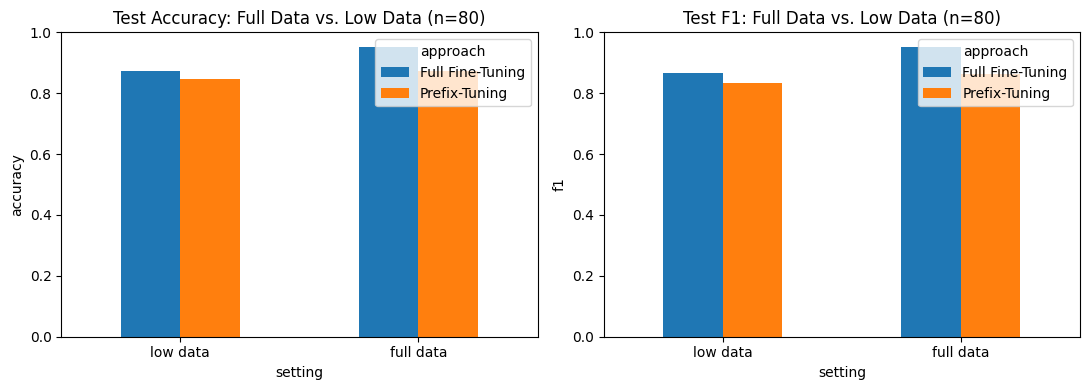

In [10]:
import matplotlib.pyplot as plt

plot_df = pd.DataFrame(results).set_index("method")
plot_df["setting"] = plot_df.index.str.extract(r"\((.*)\)")[0].values
plot_df["approach"] = plot_df.index.str.replace(r"\s*\(.*\)", "", regex=True).values

pivot = plot_df.pivot(index="setting", columns="approach", values="accuracy").loc[["low data", "full data"]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pivot.plot(kind="bar", ax=axes[0])
axes[0].set_title("Test Accuracy: Full Data vs. Low Data (n=80)")
axes[0].set_ylabel("accuracy")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=0)

pivot_f1 = plot_df.pivot(index="setting", columns="approach", values="f1").loc[["low data", "full data"]]
pivot_f1.plot(kind="bar", ax=axes[1])
axes[1].set_title("Test F1: Full Data vs. Low Data (n=80)")
axes[1].set_ylabel("f1")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Takeaways

- **Efficiency**: prefix-tuning trained ~185K parameters here (`prefix_len=10` across 12 layers) &mdash; **0.17% of BERT's backbone**, matching the paper's headline "~0.1% of parameters" figure closely.
- **Full-data setting**: full fine-tuning reached 95.3% accuracy vs. prefix-tuning's 87.3% &mdash; a real gap, not an exact match, on this particular task/model/dataset size. The paper's "comparable in full data" claim doesn't fully replicate at this scale; a wider gap here is plausible since prefix-tuning was tuned by the paper for large generative LMs (GPT-2/BART) doing generation, not a mid-size encoder doing binary classification.
- **Low-data setting (the key claim) &mdash; partially confirmed**: shrinking the training set from 850 &rarr; 80 examples dropped full fine-tuning's accuracy by **8.0 points** (95.3% &rarr; 87.3%), while prefix-tuning dropped by only **2.6 points** (87.3% &rarr; 84.7%). Prefix-tuning is clearly **far more robust to data scarcity**, exactly as the paper's "fewer trainable parameters regularizes against overfitting" mechanism predicts. However, full fine-tuning still edges out prefix-tuning in *absolute* low-data accuracy here (87.3% vs. 84.7%) &mdash; the paper's stronger claim that prefix-tuning *outperforms* fine-tuning in low data didn't fully reproduce at this data scale/task. That crossover likely needs an even smaller training set (or a harder/more overfitting-prone task) to actually observe on this setup; the *trend* (much smaller degradation) is what's most attributable to the mechanism the paper describes.
- **On data**: `data/toxicity_en.csv` (1,000 rows) was enough to *demonstrate the trend* (differential robustness to data scarcity) but not to reproduce the paper's *exact* low-data crossover result. To see prefix-tuning actually overtake full fine-tuning, try shrinking `LOW_DATA_N` further (e.g. 20-40 examples) or repeating at multiple sizes to trace out the full degradation curve. Reproducing the paper's literal numbers would require its actual benchmarks (E2E, WebNLG, XSum) and generation metrics (BLEU/ROUGE), not a classification setup like this one.